In [7]:
# Cell 1: Master Benchmark Table 3 framework × 3 dataset
import pandas as pd, numpy as np, matplotlib.pyplot as plt

master = [
    # Diabetes
    {'Dataset':'Diabetes','Task':'Binary Cls','Framework':'NumPy Scratch',
     'Accuracy':0.7495,'F1':0.7667,'Params':52138,'Time(s)':32.08},
    {'Dataset':'Diabetes','Task':'Binary Cls','Framework':'PyTorch Baseline',
     'Accuracy':0.7672,'F1':0.7302,'Params':1762,'Time(s)':3.63},
    {'Dataset':'Diabetes','Task':'Binary Cls','Framework':'PyTorch Improved',
     'Accuracy':0.7759,'F1':0.7419,'Params':9122,'Time(s)':5.2},
    {'Dataset':'Diabetes','Task':'Binary Cls','Framework':'TensorFlow',
     'Accuracy':0.6983,'F1':0.6502,'Params':1762,'Time(s)':13.61},
    # House Price
    {'Dataset':'House Price','Task':'Regression','Framework':'NumPy Scratch',
     'MAE':1.407,'RMSE':1.755,'R2':0.368,'Time(s)':146.29},
    {'Dataset':'House Price','Task':'Regression','Framework':'PyTorch Baseline',
     'MAE':1.312,'RMSE':1.646,'R2':0.445,'Time(s)':71.21},
    {'Dataset':'House Price','Task':'Regression','Framework':'PyTorch Improved',
     'MAE':1.323,'RMSE':1.652,'R2':0.440,'Time(s)':129.91},
    {'Dataset':'House Price','Task':'Regression','Framework':'TensorFlow',
     'MAE':1.294,'RMSE':1.642,'R2':0.447,'Time(s)':85.33},
    # Comments
    {'Dataset':'Comments','Task':'Binary Cls','Framework':'NumPy Scratch',
     'Accuracy':0.818,'F1':0.900,'Params':None,'Time(s)':25.49},
    {'Dataset':'Comments','Task':'Binary Cls','Framework':'PyTorch Baseline',
     'Accuracy':0.869,'F1':0.923,'Params':128514,'Time(s)':18.95},
    {'Dataset':'Comments','Task':'Binary Cls','Framework':'PyTorch Improved',
     'Accuracy':0.8805,'F1':0.925,'Params':479745,'Time(s)':30.49},
    {'Dataset':'Comments','Task':'Binary Cls','Framework':'TensorFlow',
     'Accuracy':0.8717,'F1':0.923,'Params':664769,'Time(s)':21.66},
]
dfm = pd.DataFrame(master)
print("="*100); print("BENCHMARK MASTER TABLE"); print("="*100)
print(dfm.to_string(index=False))
dfm.to_csv("outputs/master_benchmark.csv", index=False)

BENCHMARK MASTER TABLE
    Dataset       Task        Framework  Accuracy     F1   Params  Time(s)   MAE  RMSE    R2
   Diabetes Binary Cls    NumPy Scratch    0.7495 0.7667  52138.0    32.08   NaN   NaN   NaN
   Diabetes Binary Cls PyTorch Baseline    0.7672 0.7302   1762.0     3.63   NaN   NaN   NaN
   Diabetes Binary Cls PyTorch Improved    0.7759 0.7419   9122.0     5.20   NaN   NaN   NaN
   Diabetes Binary Cls       TensorFlow    0.6983 0.6502   1762.0    13.61   NaN   NaN   NaN
House Price Regression    NumPy Scratch       NaN    NaN      NaN   146.29 1.407 1.755 0.368
House Price Regression PyTorch Baseline       NaN    NaN      NaN    71.21 1.312 1.646 0.445
House Price Regression PyTorch Improved       NaN    NaN      NaN   129.91 1.323 1.652 0.440
House Price Regression       TensorFlow       NaN    NaN      NaN    85.33 1.294 1.642 0.447
   Comments Binary Cls    NumPy Scratch    0.8180 0.9000      NaN    25.49   NaN   NaN   NaN
   Comments Binary Cls PyTorch Baseline    0.86

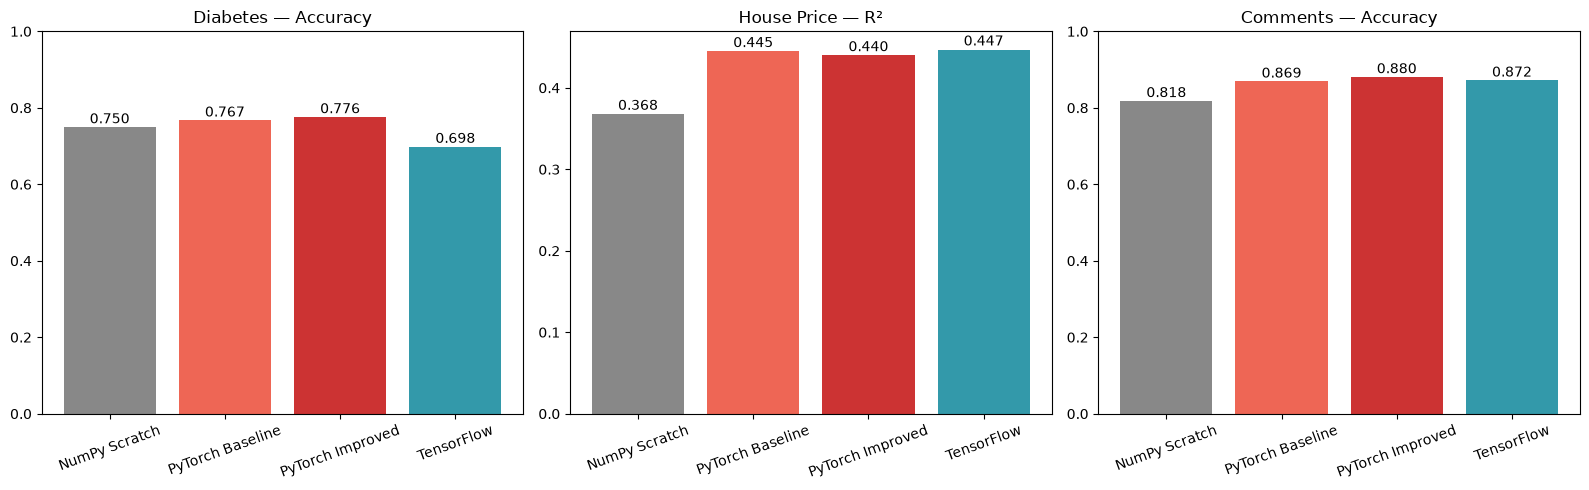

In [8]:
# Cell 2: Bar chart so sánh 3 framework
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Diabetes
d_diab = dfm[dfm['Dataset']=='Diabetes']
axes[0].bar(d_diab['Framework'], d_diab['Accuracy'], color=['#888','#e65','#c33','#39a'])
axes[0].set_title("Diabetes — Accuracy"); axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, 1)
for i, v in enumerate(d_diab['Accuracy']): axes[0].text(i, v+0.01, f"{v:.3f}", ha='center')
# House Price
d_h = dfm[dfm['Dataset']=='House Price']
axes[1].bar(d_h['Framework'], d_h['R2'], color=['#888','#e65','#c33','#39a'])
axes[1].set_title("House Price — R²"); axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(d_h['R2']): axes[1].text(i, v+0.005, f"{v:.3f}", ha='center')
# Comments
d_c = dfm[dfm['Dataset']=='Comments']
axes[2].bar(d_c['Framework'], d_c['Accuracy'], color=['#888','#e65','#c33','#39a'])
axes[2].set_title("Comments — Accuracy"); axes[2].tick_params(axis='x', rotation=20)
axes[2].set_ylim(0, 1)
for i, v in enumerate(d_c['Accuracy']): axes[2].text(i, v+0.01, f"{v:.3f}", ha='center')
plt.tight_layout(); plt.savefig("outputs/master_framework_bars.png", dpi=200); plt.show()

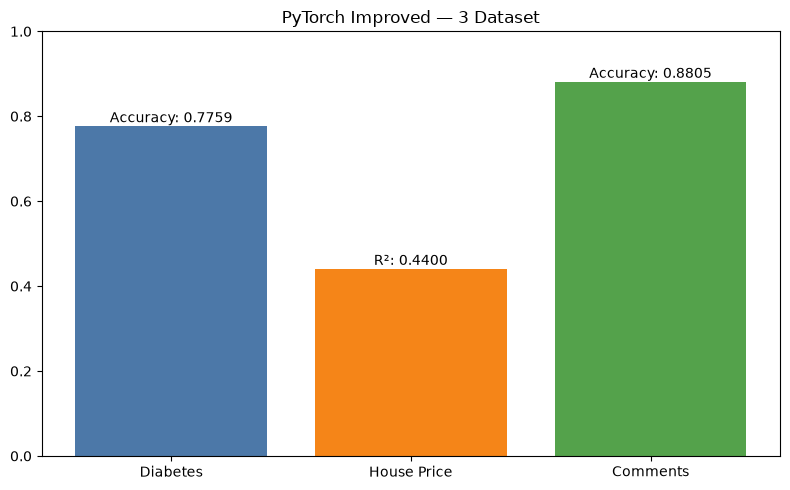

In [9]:
# Cell 3: So sánh 3 dataset cùng framework PyTorch Improved
fig, ax = plt.subplots(figsize=(8, 5))
datasets = ['Diabetes', 'House Price', 'Comments']
metrics = [0.7759, 0.440, 0.8805]
labels = ['Accuracy', 'R²', 'Accuracy']
colors = ['#4C78A8', '#F58518', '#54A24B']
bars = ax.bar(datasets, metrics, color=colors)
for b, m, l in zip(bars, metrics, labels):
    ax.text(b.get_x()+b.get_width()/2, m+0.01, f"{l}: {m:.4f}", ha='center')
ax.set_ylim(0, 1); ax.set_title("PyTorch Improved — 3 Dataset")
plt.tight_layout(); plt.savefig("outputs/master_datasets.png", dpi=200); plt.show()

In [11]:
# Cell 4: Tổng kết tự động
print("="*80)
print("TỔNG KẾT ĐỐI CHUẨN")
print("="*80)
for ds in ['Diabetes','House Price','Comments']:
    sub = dfm[dfm['Dataset']==ds]
    
    if sub['Accuracy'].notna().any():
        best = sub.loc[sub['Accuracy'].idxmax()]
    else:
        best = sub.loc[sub['R2'].idxmax()]
        
    print(f"\n[{ds}]")
    print(sub.to_string(index=False))
    print(f"Best: {best['Framework']}")
    
print("\n=> Kết luận: 'Same mathematical model ≠ same implementation'")
print("   Framework chỉ ảnh hưởng tốc độ và độ tiện dụng, không quyết định chất lượng.")

TỔNG KẾT ĐỐI CHUẨN

[Diabetes]
 Dataset       Task        Framework  Accuracy     F1  Params  Time(s)  MAE  RMSE  R2
Diabetes Binary Cls    NumPy Scratch    0.7495 0.7667 52138.0    32.08  NaN   NaN NaN
Diabetes Binary Cls PyTorch Baseline    0.7672 0.7302  1762.0     3.63  NaN   NaN NaN
Diabetes Binary Cls PyTorch Improved    0.7759 0.7419  9122.0     5.20  NaN   NaN NaN
Diabetes Binary Cls       TensorFlow    0.6983 0.6502  1762.0    13.61  NaN   NaN NaN
Best: PyTorch Improved

[House Price]
    Dataset       Task        Framework  Accuracy  F1  Params  Time(s)   MAE  RMSE    R2
House Price Regression    NumPy Scratch       NaN NaN     NaN   146.29 1.407 1.755 0.368
House Price Regression PyTorch Baseline       NaN NaN     NaN    71.21 1.312 1.646 0.445
House Price Regression PyTorch Improved       NaN NaN     NaN   129.91 1.323 1.652 0.440
House Price Regression       TensorFlow       NaN NaN     NaN    85.33 1.294 1.642 0.447
Best: TensorFlow

[Comments]
 Dataset       Task        